# バスモデルとSIRモデル：マーケティングと感染症数理の意外な関係


## はじめに

これまで、新製品の普及を予測する**バスモデル**について解説してきた。
一方で、昨今のパンデミックにより、感染症の拡大を予測する**SIRモデル**という言葉を耳にする機会が増えたので１度整理しておく。

実は、マーケティングにおける「情報の伝播（口コミ）」と、疫学における「ウイルスの伝播（感染）」は、数理的には驚くほど似ている。

本記事では、バスモデルとSIRモデルを比較し、その共通点と決定的な違いについて解説する。

## ソースコード

### GitHub
- Jupyter Notebook形式のファイルは[こちら](https://github.com/hiroshi0530/wa-src/blob/master/rec/stats/04/04_nb.ipynb)

### Google Colaboratory
- Google Colaboratory で実行する場合は[こちら](https://colab.research.google.com/github/hiroshi0530/wa-src/blob/master/rec/stats/04/04_nb.ipynb)

## 実行環境
OSはmacOSである。LinuxやUnixのコマンドとはオプションが異なることに注意されたい。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.14.0


必要なライブラリをインポートする。

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# グラフのスタイル設定
plt.style.use('seaborn-v0_8-darkgrid')

## 1. バスモデルの復習

バスモデルの微分方程式は以下の通りである。

$$
\frac{dN}{dt} = \left( p + q \frac{N}{M} \right) (M - N)
$$

ここで、
- $N$: 累積採用者数
- $M$: 潜在市場規模（未採用者を含む全人口）
- $p$: イノベーション係数（広告などの外部要因）
- $q$: 模倣係数（口コミなどの内部要因）

右辺を展開すると、
$$
\frac{dN}{dt} = p(M-N) + \frac{q}{M} N (M-N)
$$
となる。
第1項は「広告による採用」、第2項は「既存採用者($N$)と未採用者($M-N$)の接触による採用」を表している。

## 2. SIRモデルの概要

SIRモデルは、人口を以下の3つの状態に分けて考える。
- **S (Susceptible)**: 未感染者（これから感染する可能性がある）
- **I (Infected)**: 感染者（他人にうつす能力がある）
- **R (Recovered)**: 回復者（免疫を獲得し、もう感染しない）

基本的な微分方程式は以下の通りである。

$$
\begin{aligned}
\frac{dS}{dt} &= -\beta S I \\
\frac{dI}{dt} &= \beta S I - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{aligned}
$$

ここで、
- $\beta$: 感染率（接触によりうつる確率）
- $\gamma$: 回復率

## 3. バスモデルとSIRモデルの比較

### 3.1 数学的な類似性

SIRモデルにおいて、回復を考えない（$\gamma=0$）単純なケース（SIモデル）を考えてみる。
全人口を $N_{total} = S + I$ （一定）とすると、$S = N_{total} - I$ となる。
感染者数 $I$ の増分は、

$$
\frac{dI}{dt} = \beta S I = \beta (N_{total} - I) I
$$

となる。

一方、バスモデルで広告効果がない（$p=0$）場合を考えると、

$$
\frac{dN}{dt} = \frac{q}{M} N (M - N)
$$

この2つの式を見比べると、構造が全く同じであることがわかる。

| バスモデル | SIモデル |
| :--- | :--- |
| 累積採用者 $N$ | 感染者 $I$ |
| 市場規模 $M$ | 全人口 $N_{total}$ |
| 模倣係数 $q$ | 感染力 $\beta N_{total}$ |

数式は完全に一致する。
つまり、**「イノベーション効果（広告など）がないバスモデル」は、「回復しない感染症モデル（SIモデル）」と数学的に等価**なのである。

### 3.2 決定的な違い

しかし、実用上は以下の2点で大きく異なる。

#### 1. 0からの立ち上がり (The "Patient Zero" Problem)
- **SI/SIRモデル**: $I(0) = 0$ だと、$\frac{dI}{dt}=0$ となり永遠に感染は始まらない。必ず最初の感染者（Patient Zero）が必要である。
- **バスモデル**: $N(0) = 0$ でも、イノベーション効果 $p(M-N)$ があるため、自発的に普及が始まる。

#### 2. 状態の可逆性 (Adoption vs Infection)
- **バスモデル**: 通常、耐久消費財（冷蔵庫や車）の購入を扱うため、一度「採用」したら累積数としてカウントされ続ける（$N(t)$ は減らない）。
- **SIRモデル**: インフルエンザのように「回復」して感染力を失うため、現在の感染者数 $I(t)$ は山なりに増減する。

SNSのアクティブユーザー数などは、登録（感染）しても飽きて離脱（回復）するため、バスモデルよりもSIRモデル（あるいはSIRSモデル）の方が近い挙動を示すことがある。

## 4. Pythonによるシミュレーション比較

実際にコードを書いて、挙動の違いを可視化してみる。
ここでは、以下の3つのモデルを比較する。

1. **Bass Model**: 標準的なバスモデル
2. **SI Model**: 回復のない感染モデル（初期感染者あり）
3. **SIR Model**: 回復のある感染モデル

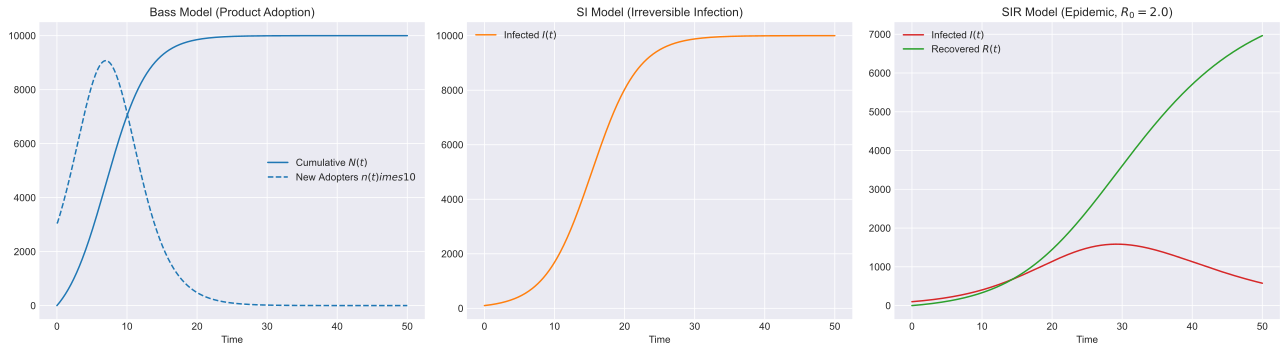

In [4]:
# モデルの定義

def bass_diff_eq(N, t, M, p, q):
    return (p + q * N / M) * (M - N)

def sir_diff_eq(y, t, N_total, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# パラメータ設定
M = 10000       # 全人口
t_max = 50
t = np.linspace(0, t_max, 500)

# 1. Bass Model (p=0.03, q=0.3)
p_bass = 0.03
q_bass = 0.3
N_bass = odeint(bass_diff_eq, 0, t, args=(M, p_bass, q_bass)).flatten()
n_bass = np.gradient(N_bass, t) # 新規採用者数

# 2. SI Model (Bassのqに対応するbetaを設定, p=0なので初期感染者が必要)
# beta * N_total = q  => beta = q / M
beta_si = q_bass / M
I0_si = 100 # 初期感染者100人 (1%)
S0_si = M - I0_si
# gamma = 0
si_result = odeint(sir_diff_eq, [S0_si, I0_si, 0], t, args=(M, beta_si, 0))
I_si = si_result[:, 1]

# 3. SIR Model (回復あり)
# R0 = 2.0 程度になるように gamma を設定
# R0 = (beta * M) / gamma = q / gamma = 2.0 => gamma = q / 2.0
gamma_sir = q_bass / 2.0
sir_result = odeint(sir_diff_eq, [S0_si, I0_si, 0], t, args=(M, beta_si, gamma_sir))
I_sir = sir_result[:, 1]
R_sir = sir_result[:, 2]

# プロット
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Bass Model
axes[0].plot(t, N_bass, label='Cumulative $N(t)$', color='tab:blue')
axes[0].plot(t, n_bass * 10, label='New Adopters $n(t) \times 10$', color='tab:blue', linestyle='--')
axes[0].set_title('Bass Model (Product Adoption)')
axes[0].set_xlabel('Time')
axes[0].legend()

# Plot 2: SI Model
axes[1].plot(t, I_si, label='Infected $I(t)$', color='tab:orange')
axes[1].set_title('SI Model (Irreversible Infection)')
axes[1].set_xlabel('Time')
axes[1].legend()

# Plot 3: SIR Model
axes[2].plot(t, I_sir, label='Infected $I(t)$', color='tab:red')
axes[2].plot(t, R_sir, label='Recovered $R(t)$', color='tab:green')
axes[2].set_title(f'SIR Model (Epidemic, $R_0={q_bass/gamma_sir:.1f}$)')
axes[2].set_xlabel('Time')
axes[2].legend()

plt.tight_layout()
plt.show()

### シミュレーション結果の考察

1. **Bass vs SI**:
   - Bassモデル（左）とSIモデル（中）の曲線形状は非常に似ている（S字カーブ）。
   - 違いは初期条件である。Bassは0からスタートできるが、SIは初期値（$I_0=100$）を与えないと立ち上がらない。
   - マーケティングにおいて「広告（$p$）」がいかに重要か、あるいは「インフルエンサーへの種まき（$I_0$）」がいかに重要かがわかる。

2. **SIRモデルの特徴**:
   - SIRモデル（右）では、感染者数 $I(t)$（赤線）はピークを迎えた後に減少に転じる。
   - これは「回復」によって感染源が減るためである。
   - 流行性のゲームやSNSアプリのアクティブユーザー推移は、累積型のBassモデルよりも、このSIRモデルに近い挙動を示すことがよくある。

## 5. 応用：サービスの「生存」条件

SIRモデルの知見をサブスクリプションサービスに応用してみる。
サービスにおける「回復」は「解約（Churn）」に対応する。

基本再生産数 $R_0 = \frac{\beta N_{total}}{\gamma}$ をサービスの言葉に翻訳すると、

$$
R_0 = \frac{\text{バイラル係数} \times \text{潜在顧客数}}{\text{解約率}}
$$

となる（厳密な定義は文脈によるが、概念的に）。
$R_0 > 1$ を維持することが、サービスが自律的に成長するための条件である。
つまり、
- 口コミ力を高める（$\beta$ を上げる）
- 解約率を下げる（$\gamma$ を下げる）

のどちらか（あるいは両方）が必要不可欠であることが、数理モデルからも明らかになる。

## 結論

本記事では、バスモデルとSIRモデルを比較し、その数学的な等価性と構造的な違いを解説した。

- **バスモデル**: 耐久消費財の累積普及予測に適している。広告効果（$p$）を含み、0からの立ち上がりを扱える。
- **SIRモデル**: 流行性のサービスや感染症に適している。回復（解約）を考慮し、アクティブ数の増減を扱える。

扱う商材や現象の性質に合わせて、適切なモデルを選択（あるいは拡張）することがとても重要である。